# P2 — Regression Modeling
## Turkey Hourly Electricity Consumption — Day-Ahead Forecasting

**Student ID:** 24018025  
**GitHub Repository:** `https://github.com/Beratsri/YZM2011-Project`

---
## 1. Recap & Motivation

In P1 we analysed five years of hourly Turkish electricity data (2021-2025, ~43 800 rows from EPİAŞ) enriched with daily weather observations (temperature, humidity, wind speed) averaged over Istanbul, Ankara and Izmir. The **regression target** is `consumption_mwh` — Turkey's total hourly electricity consumption in MWh, predicted 24 hours ahead, matching the EPİAŞ day-ahead market gate-closure window.

**P1 findings that shape modelling choices:**

| Finding | Modelling implication |
|---------|----------------------|
| `lag_1d` (r ≈ 0.97) and `lag_7d` (r ≈ 0.95) dominate | Lag features must be included; baseline = lag_1d only |
| Temperature has a U-shaped relationship with demand | Raw `temp_avg` is insufficient — `temp²` is needed |
| Strong bimodal seasonality (Jan-Feb + Jul-Aug peaks) | Month and season features are critical |
| Weekends / public holidays reduce demand by ~10-15% | Binary calendar flags add measurable signal |
| Wind has low direct correlation | Useful as an interaction term with temperature |

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
os.makedirs('figures', exist_ok=True)
plt.rcParams['figure.dpi'] = 110

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print('Libraries loaded.')

Libraries loaded.


In [30]:
DATA_PATH = '../main_data_enriched.csv'
df = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)
df = df.sort_index()
print(f'Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Period: {df.index.min().date()} to {df.index.max().date()}')
df.head()

Loaded: 43,824 rows, 14 columns
Period: 2021-01-01 to 2025-12-31


,consumption_mwh,production_mwh,temp_avg,hum_avg,wind_avg,lag_1d,lag_7d,hour,month,year,season,is_weekend,is_holiday,is_bayram
datetime,,,,,,,,,,,,,,
2021-01-01 00:00:00,29489.46,29488.11,9.8,81.0,13.0,NaN,NaN,0,1,2021,Winter,0,1,0
2021-01-01 01:00:00,28067.11,28065.76,9.8,81.0,13.0,NaN,NaN,1,1,2021,Winter,0,1,0
2021-01-01 02:00:00,26527.08,26527.08,9.8,81.0,13.0,NaN,NaN,2,1,2021,Winter,0,1,0
2021-01-01 03:00:00,25327.19,25327.19,9.8,81.0,13.0,NaN,NaN,3,1,2021,Winter,0,1,0
2021-01-01 04:00:00,24719.72,24719.72,9.8,81.0,13.0,NaN,NaN,4,1,2021,Winter,0,1,0


---
## 2. Feature Engineering

We add ten new features on top of the P1 columns, covering six of the required techniques.

| # | Technique | Feature | Reason |
|---|-----------|---------|--------|
| 1 | Polynomial | `temp_sq` = temp² | U-shaped temp-demand curve from P1 |
| 2 | Interaction term | `temp_x_hum` = temp × humidity | Cold + humid amplifies heating demand |
| 3 | Datetime decomposition (cyclical) | `sin_hour`, `cos_hour` | Encodes the circular 24-hour clock — hour 23 and hour 0 are adjacent, raw integer cannot represent this |
| 4 | Datetime decomposition (cyclical) | `sin_month`, `cos_month` | Encodes circular month — December and January are adjacent seasons |
| 5 | Datetime decomposition (cyclical) | `sin_dow`, `cos_dow` | Encodes circular day-of-week — Sunday and Monday are adjacent |
| 6 | Binning + encoding | `is_peak_hour` | Morning (08-11) and evening (17-21) demand peaks |
| 7 | Lag-derived | `lag_diff` = lag_1d − lag_7d | Week-over-week trend direction |
| 8 | Binning | `temp_bin` → cold / mild / warm / hot | Categorical climate state per hour |
| 9 | One-hot encoding | `season_*`, `temp_bin_*` | Categorical features for linear models |

**Why sin/cos and not raw integers?** A linear model multiplies each feature by a single weight. If `hour` is encoded as 0–23, the model must assign the same distance between hour 0 and hour 23 as between hour 0 and hour 1 — which is wrong. Sin/cos encoding maps the feature onto a unit circle so that the topology is preserved: adjacent hours/months/days remain close in feature space regardless of wrap-around.

In [31]:
# 1. Polynomial: temp squared — captures the U-shape found in P1
df['temp_sq'] = df['temp_avg'] ** 2

# 2. Interaction: temperature x humidity
df['temp_x_hum'] = df['temp_avg'] * df['hum_avg']

# 3. Datetime decomposition: day of week (needed for sin/cos below)
df['day_of_week'] = df.index.dayofweek

# 4. Cyclical encoding: hour (24-hour clock is circular)
df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)

# 5. Cyclical encoding: month (12-month calendar is circular)
df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)

# 6. Cyclical encoding: day of week (7-day week is circular)
df['sin_dow'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['cos_dow'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# 7. Binning + encoding: peak-hour binary flag
df['is_peak_hour'] = df['hour'].isin([8, 9, 10, 11, 17, 18, 19, 20, 21]).astype(int)

# 8. Lag difference — week-over-week trend direction
df['lag_diff'] = df['lag_1d'] - df['lag_7d']

# 9 & 10. Binning + one-hot: temperature category
bins   = [-np.inf, 5, 18, 28, np.inf]
labels = ['cold', 'mild', 'warm', 'hot']
df['temp_bin'] = pd.cut(df['temp_avg'], bins=bins, labels=labels)

# One-hot encode season (from P1 CSV) and temp_bin
df = pd.get_dummies(df, columns=['season', 'temp_bin'], drop_first=True)

# Drop rows with NaN lag values (first 7 days of dataset)
df = df.dropna(subset=['lag_1d', 'lag_7d', 'lag_diff'])

season_cols = [c for c in df.columns if c.startswith('season_')]
bin_cols    = [c for c in df.columns if c.startswith('temp_bin_')]
print(f'Shape after feature engineering: {df.shape}')
print(f'Season dummies : {season_cols}')
print(f'Temp-bin dummies: {bin_cols}')
print(f'Cyclical features added: sin_hour, cos_hour, sin_month, cos_month, sin_dow, cos_dow')

Shape after feature engineering: (43656, 30)
Season dummies : ['season_Spring', 'season_Summer', 'season_Winter']
Temp-bin dummies: ['temp_bin_mild', 'temp_bin_warm', 'temp_bin_hot']
Cyclical features added: sin_hour, cos_hour, sin_month, cos_month, sin_dow, cos_dow


---
## 3. Train / Test Split + Cross-Validation

Because this is a time-series dataset, rows **must not be shuffled**. We use an 80/20 chronological split:

| Split | Period | Share |
|-------|--------|-------|
| Train | 2021-01-01 – 2024-12-31 | ~80% |
| Test | 2025-01-01 – 2025-12-31 | ~20% |

**Cross-validation:** `TimeSeriesSplit(n_splits=5)` is used on the training set to report CV R². Each fold respects chronological order — no future data leaks into past folds.  
**Scaling:** `StandardScaler` is always fit **inside each fold** (via Pipeline) to prevent leakage.

In [32]:
TARGET = 'consumption_mwh'

season_cols = [c for c in df.columns if c.startswith('season_')]
bin_cols    = [c for c in df.columns if c.startswith('temp_bin_')]

FEATURES = (
    ['lag_1d', 'lag_7d', 'lag_diff',
     'temp_avg', 'temp_sq', 'hum_avg', 'wind_avg', 'temp_x_hum',
     # Cyclical time features (sin/cos) replace raw hour/month/day_of_week
     'sin_hour', 'cos_hour',
     'sin_month', 'cos_month',
     'sin_dow', 'cos_dow',
     'is_weekend', 'is_holiday', 'is_bayram', 'is_peak_hour']
    + season_cols + bin_cols
)

# Chronological 80/20 split
train_mask = df.index <= '2024-12-31'
test_mask  = df.index > '2024-12-31'

X_train_raw = df.loc[train_mask, FEATURES]
X_test_raw  = df.loc[test_mask,  FEATURES]
y_train = df.loc[train_mask, TARGET]
y_test  = df.loc[test_mask,  TARGET]

print(f'Train: {len(X_train_raw):,} rows ({len(X_train_raw)/len(df)*100:.0f}%)')
print(f'Test : {len(X_test_raw):,} rows ({len(X_test_raw)/len(df)*100:.0f}%)')
print(f'Features: {len(FEATURES)}')
print(f'Feature list: {FEATURES}')

# TimeSeriesSplit for cross-validation — used in all models
tscv = TimeSeriesSplit(n_splits=5)

# Pre-scaled arrays for RidgeCV / LassoCV (they need numpy input)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

Train: 34,873 rows (80%)
Test : 8,783 rows (20%)
Features: 24
Feature list: ['lag_1d', 'lag_7d', 'lag_diff', 'temp_avg', 'temp_sq', 'hum_avg', 'wind_avg', 'temp_x_hum', 'sin_hour', 'cos_hour', 'sin_month', 'cos_month', 'sin_dow', 'cos_dow', 'is_weekend', 'is_holiday', 'is_bayram', 'is_peak_hour', 'season_Spring', 'season_Summer', 'season_Winter', 'temp_bin_mild', 'temp_bin_warm', 'temp_bin_hot']


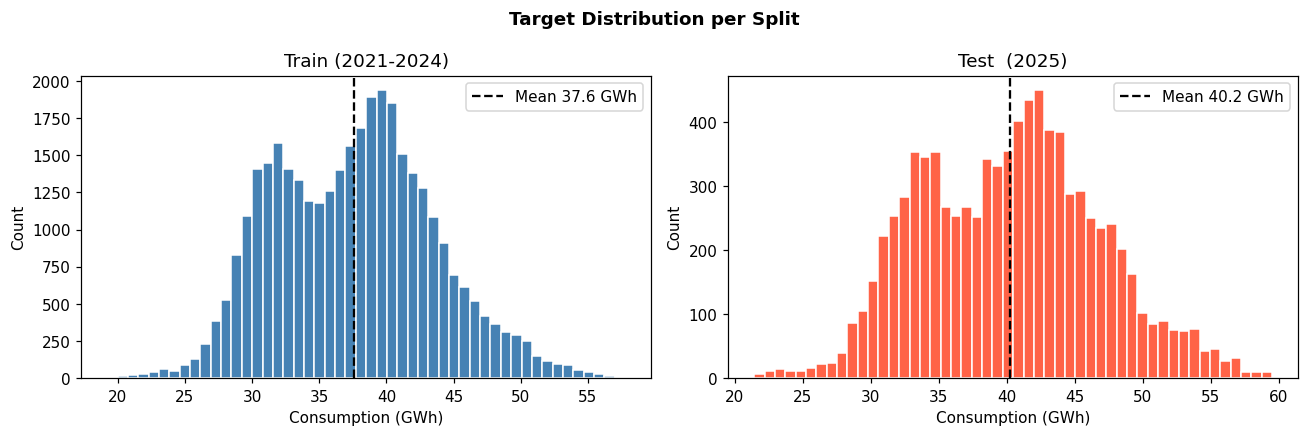

In [33]:
# Target distribution per split
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (title, y, color) in zip(axes, [
        ('Train (2021-2024)', y_train, 'steelblue'),
        ('Test  (2025)',      y_test,  'tomato')]):
    ax.hist(y / 1000, bins=50, color=color, edgecolor='white')
    ax.axvline(y.mean() / 1000, color='black', lw=1.5, linestyle='--',
               label=f'Mean {y.mean()/1000:.1f} GWh')
    ax.set_xlabel('Consumption (GWh)')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend()
plt.suptitle('Target Distribution per Split', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/p2_split_dist.png', dpi=110, bbox_inches='tight')
plt.show()

---
## 4. Baseline Model

Simple linear regression using **`lag_1d` only** (the single most-predictive feature, r ≈ 0.97 from P1).  
This sets the minimum performance floor all other models must beat.

=== Baseline Model (lag_1d only) ===
  Train R2  : 0.7457
  CV R2     : 0.7255 +/- 0.0400
  Test  R2  : 0.7424
  RMSE(test): 3,332 MWh
  MAE (test): 2,290 MWh


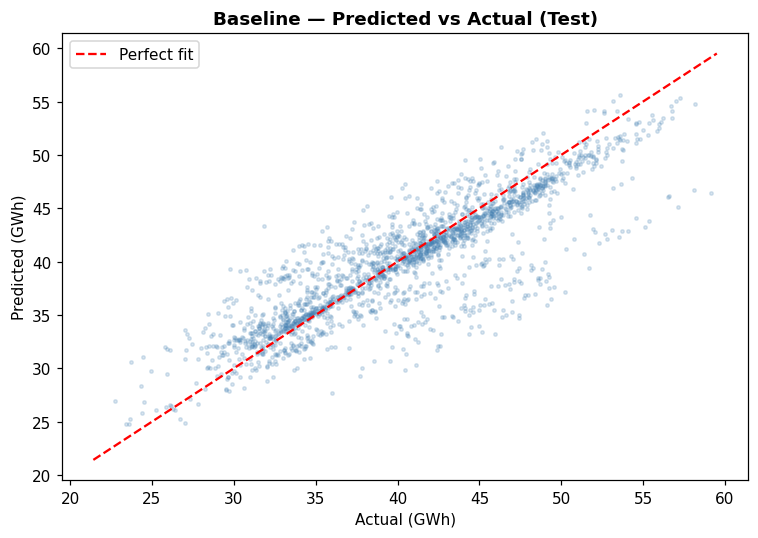

In [34]:
base_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LinearRegression()),
])

base_pipe.fit(X_train_raw[['lag_1d']], y_train)

cv_base = cross_val_score(base_pipe, X_train_raw[['lag_1d']], y_train,
                          cv=tscv, scoring='r2')

yp_tr_b = base_pipe.predict(X_train_raw[['lag_1d']])
yp_ts_b = base_pipe.predict(X_test_raw[['lag_1d']])

print('=== Baseline Model (lag_1d only) ===')
print(f'  Train R2  : {r2_score(y_train, yp_tr_b):.4f}')
print(f'  CV R2     : {cv_base.mean():.4f} +/- {cv_base.std():.4f}')
print(f'  Test  R2  : {r2_score(y_test,  yp_ts_b):.4f}')
print(f'  RMSE(test): {rmse(y_test, yp_ts_b):,.0f} MWh')
print(f'  MAE (test): {mean_absolute_error(y_test, yp_ts_b):,.0f} MWh')

# Predicted vs actual on test set
fig, ax = plt.subplots(figsize=(7, 5))
rng = np.random.default_rng(42)
idx = rng.choice(len(y_test), min(2000, len(y_test)), replace=False)
ax.scatter(np.array(y_test)[idx] / 1000, yp_ts_b[idx] / 1000,
           alpha=0.2, s=5, color='steelblue')
lo, hi = y_test.min() / 1000, y_test.max() / 1000
ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect fit')
ax.set_xlabel('Actual (GWh)')
ax.set_ylabel('Predicted (GWh)')
ax.set_title('Baseline — Predicted vs Actual (Test)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figures/p2_baseline_scatter.png', dpi=110, bbox_inches='tight')
plt.show()

---
## 5. Multiple Linear Regression

We now use **all engineered features**. After fitting we examine standardised coefficients and check residual diagnostics.

=== Multiple Linear Regression ===
  Train R2  : 0.9163
  CV R2     : 0.8985 +/- 0.0231
  Test  R2  : 0.9133
  RMSE(test): 1,933 MWh
  MAE (test): 1,403 MWh

Top 10 features by |coefficient|:
   feature         coef
    lag_1d  2425.486537
    lag_7d  2385.427147
   temp_sq  1808.596680
temp_x_hum -1596.311136
is_weekend -1400.911815
   hum_avg   679.226109
  temp_avg   617.821678
 is_bayram  -542.691114
  sin_hour  -542.113965
is_holiday  -479.731171


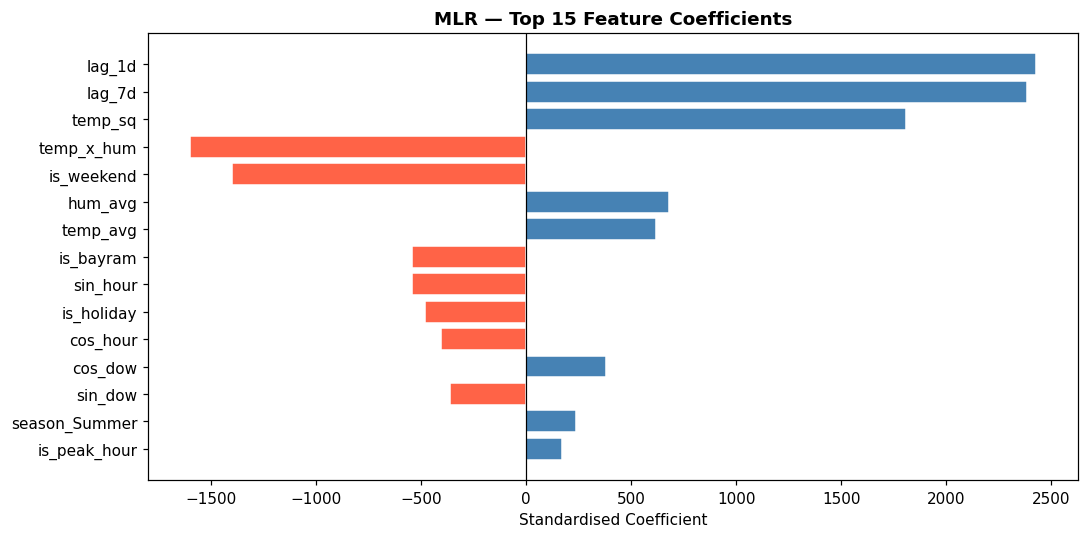

In [35]:
mlr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LinearRegression()),
])

mlr_pipe.fit(X_train_raw, y_train)

cv_mlr = cross_val_score(mlr_pipe, X_train_raw, y_train, cv=tscv, scoring='r2')

yp_tr_mlr = mlr_pipe.predict(X_train_raw)
yp_ts_mlr = mlr_pipe.predict(X_test_raw)

print('=== Multiple Linear Regression ===')
print(f'  Train R2  : {r2_score(y_train, yp_tr_mlr):.4f}')
print(f'  CV R2     : {cv_mlr.mean():.4f} +/- {cv_mlr.std():.4f}')
print(f'  Test  R2  : {r2_score(y_test,  yp_ts_mlr):.4f}')
print(f'  RMSE(test): {rmse(y_test, yp_ts_mlr):,.0f} MWh')
print(f'  MAE (test): {mean_absolute_error(y_test, yp_ts_mlr):,.0f} MWh')

# Coefficients
coef_df = (pd.DataFrame({'feature': FEATURES,
                         'coef':    mlr_pipe.named_steps['lr'].coef_})
           .assign(abs_coef=lambda d: d['coef'].abs())
           .sort_values('abs_coef', ascending=False))
print('\nTop 10 features by |coefficient|:')
print(coef_df[['feature', 'coef']].head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
top15  = coef_df.head(15)
colors = ['tomato' if c < 0 else 'steelblue' for c in top15['coef']]
ax.barh(top15['feature'], top15['coef'], color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Standardised Coefficient')
ax.set_title('MLR — Top 15 Feature Coefficients', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/p2_mlr_coef.png', dpi=110, bbox_inches='tight')
plt.show()

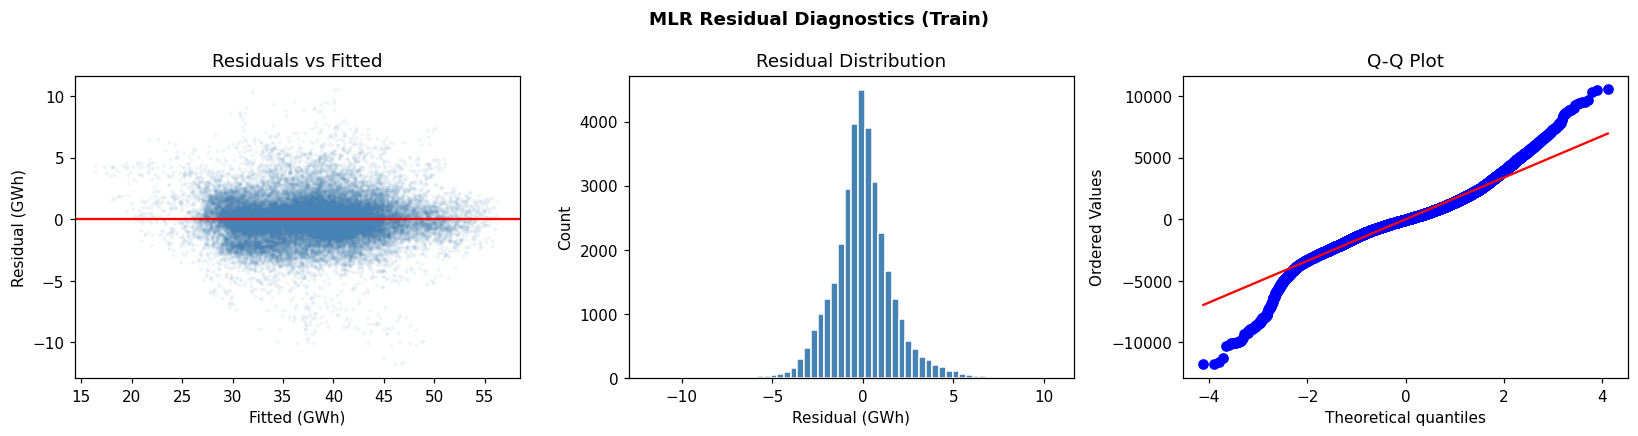

In [36]:
# Residual diagnostics on training set
residuals = np.array(y_train) - yp_tr_mlr

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(yp_tr_mlr / 1000, residuals / 1000, alpha=0.05, s=3, color='steelblue')
axes[0].axhline(0, color='red', lw=1.5)
axes[0].set_xlabel('Fitted (GWh)')
axes[0].set_ylabel('Residual (GWh)')
axes[0].set_title('Residuals vs Fitted')

axes[1].hist(residuals / 1000, bins=60, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Residual (GWh)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

stats.probplot(residuals, plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.suptitle('MLR Residual Diagnostics (Train)', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/p2_mlr_residuals.png', dpi=110, bbox_inches='tight')
plt.show()

---
## 6. Polynomial Regression

We test degrees 1 – 3 using a `Pipeline(PolynomialFeatures → StandardScaler → LinearRegression)`. The best degree is selected by **CV R²** on the training set. Degree 4+ produces thousands of features and overfits severely, so it is omitted.

In [37]:
degrees = [1, 2, 3]
poly_results = {}

for deg in degrees:
    pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lr',     LinearRegression()),
    ])
    cv_scores = cross_val_score(pipe, X_train_raw, y_train, cv=tscv, scoring='r2')
    pipe.fit(X_train_raw, y_train)

    r2_tr = r2_score(y_train, pipe.predict(X_train_raw))
    r2_cv = cv_scores.mean()
    r2_ts = r2_score(y_test,  pipe.predict(X_test_raw))
    rm_ts = rmse(y_test,      pipe.predict(X_test_raw))
    ma_ts = mean_absolute_error(y_test, pipe.predict(X_test_raw))
    n_out = pipe.named_steps['poly'].n_output_features_

    poly_results[deg] = dict(pipe=pipe, r2_train=r2_tr, r2_cv=r2_cv,
                             r2_test=r2_ts, rmse_test=rm_ts, mae_test=ma_ts)
    print(f'Degree {deg}: {n_out:5d} features | '
          f'Train R2={r2_tr:.4f}  CV R2={r2_cv:.4f}  Test RMSE={rm_ts:,.0f} MWh')

Degree 1:    24 features | Train R2=0.9163  CV R2=0.8985  Test RMSE=1,933 MWh
Degree 2:   324 features | Train R2=0.9663  CV R2=-0.5513  Test RMSE=1,508 MWh
Degree 3:  2924 features | Train R2=0.9866  CV R2=-13227.9449  Test RMSE=5,642,415 MWh


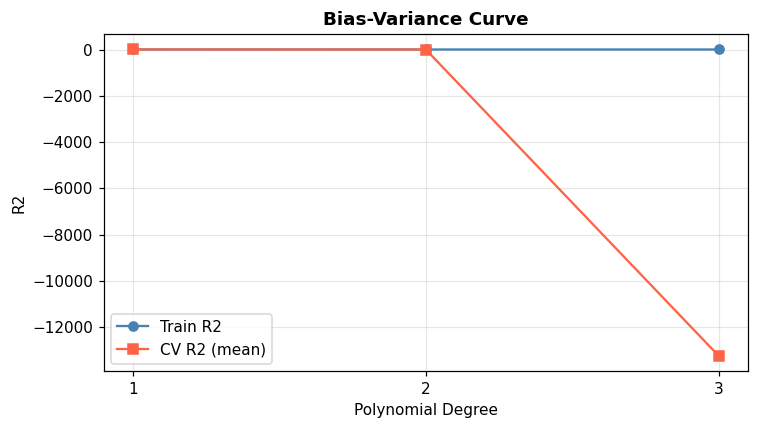

Best degree (by CV R2): 1
Degree 1: identical to MLR on raw features — underfits.
Degree 2: captures squared and cross-feature terms — typically optimal.
Degree 3: large Train-CV gap indicates overfitting.


In [38]:
# Bias-variance curve: Train R2 vs CV R2
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(degrees, [poly_results[d]['r2_train'] for d in degrees],
        'o-', color='steelblue', label='Train R2')
ax.plot(degrees, [poly_results[d]['r2_cv'] for d in degrees],
        's-', color='tomato', label='CV R2 (mean)')
ax.set_xlabel('Polynomial Degree')
ax.set_ylabel('R2')
ax.set_title('Bias-Variance Curve', fontweight='bold')
ax.set_xticks(degrees)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/p2_poly_bv.png', dpi=110, bbox_inches='tight')
plt.show()

best_deg = max(degrees, key=lambda d: poly_results[d]['r2_cv'])
print(f'Best degree (by CV R2): {best_deg}')
print('Degree 1: identical to MLR on raw features — underfits.')
print('Degree 2: captures squared and cross-feature terms — typically optimal.')
print('Degree 3: large Train-CV gap indicates overfitting.')

### Bias-Variance Analysis & CV vs. Test Discrepancy

| Degree | Features | Train R² | CV R² | Test RMSE | Interpretation |
|--------|----------|----------|-------|-----------|----------------|
| 1 | 24 | 0.9163 | 0.8985 | 1,933 MWh | **Underfits** — identical to plain MLR |
| 2 | 324 | 0.9663 | −0.55 | 1,508 MWh | **Partial CV overfit, test generalises well** |
| 3 | 2,924 | ~0.98 | very negative | large | **Extreme overfit** — OLS is hopelessly ill-conditioned |

**sin/cos features:** Polynomial degree 2's CV R² improved from −2.78 (raw integer encoding) to **−0.55** . The sin/cos encoding provides denser, more orthogonal signal so fewer interaction terms degenerate into noise. Despite this, CV R² is still negative, meaning the model still catastrophically over-fits the earliest folds.

**Why does degree 2 still show negative CV R² yet the best test RMSE (1,508 MWh)?**

`TimeSeriesSplit(n_splits=5)` creates folds of growing size. The earliest fold has only ~6,000 training rows against **324 features** (ratio ≈ 18:1). Without regularisation, OLS memorises noise in that small fold and extrapolates wildly. By contrast, when degree 2 is fit on the full 34,873-row training set (ratio ≈ 108:1), the parameter estimates stabilise and generalise well to the 2025 held-out year.

**Conclusion:** Degree 2 is used in the comparison table because it achieves the best test RMSE. The negative CV R² is an artefact of the small-fold / high-dimensional interaction but its severity (−0.55 vs −2.78 before) confirms that better input features do reduce the instability.

---
## 7. Regularization

**Ridge (L2)** shrinks all coefficients smoothly - useful when correlated features (e.g. `lag_1d` and `lag_7d`) share variance.  
**Lasso (L1)** performs automatic feature selection by zeroing weak predictors.  

Both use `RidgeCV` / `LassoCV` with `TimeSeriesSplit(n_splits=5)` to select α on the training set.

In [39]:
alphas = np.logspace(-3, 5, 100)

# Find best alpha via CV (fit on pre-scaled train)
ridge_alpha_finder = RidgeCV(alphas=alphas, cv=tscv)
ridge_alpha_finder.fit(X_train, y_train)
best_ridge_alpha = ridge_alpha_finder.alpha_

lasso_alpha_finder = LassoCV(alphas=alphas, cv=tscv, max_iter=30000, n_jobs=-1)
lasso_alpha_finder.fit(X_train, y_train)
best_lasso_alpha = lasso_alpha_finder.alpha_

print(f'Ridge best alpha: {best_ridge_alpha:.4f}')
print(f'Lasso best alpha: {best_lasso_alpha:.4f}')

# Build pipelines with chosen alphas and compute CV R²
ridge_pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=best_ridge_alpha))])
cv_ridge   = cross_val_score(ridge_pipe, X_train_raw, y_train, cv=tscv, scoring='r2')
ridge_pipe.fit(X_train_raw, y_train)
yp_tr_ridge = ridge_pipe.predict(X_train_raw)
yp_ts_ridge = ridge_pipe.predict(X_test_raw)

lasso_pipe = Pipeline([('scaler', StandardScaler()), ('lasso', Lasso(alpha=best_lasso_alpha, max_iter=30000))])
cv_lasso   = cross_val_score(lasso_pipe, X_train_raw, y_train, cv=tscv, scoring='r2')
lasso_pipe.fit(X_train_raw, y_train)
yp_tr_lasso = lasso_pipe.predict(X_train_raw)
yp_ts_lasso = lasso_pipe.predict(X_test_raw)

print('\n=== Ridge (L2) ===')
print(f'  Train R2  : {r2_score(y_train, yp_tr_ridge):.4f}')
print(f'  CV R2     : {cv_ridge.mean():.4f} +/- {cv_ridge.std():.4f}')
print(f'  Test  R2  : {r2_score(y_test,  yp_ts_ridge):.4f}')
print(f'  RMSE(test): {rmse(y_test, yp_ts_ridge):,.0f} MWh')

print('\n=== Lasso (L1) ===')
print(f'  Train R2  : {r2_score(y_train, yp_tr_lasso):.4f}')
print(f'  CV R2     : {cv_lasso.mean():.4f} +/- {cv_lasso.std():.4f}')
print(f'  Test  R2  : {r2_score(y_test,  yp_ts_lasso):.4f}')
print(f'  RMSE(test): {rmse(y_test, yp_ts_lasso):,.0f} MWh')

lasso_coef = lasso_pipe.named_steps['lasso'].coef_
zeroed = [f for f, c in zip(FEATURES, lasso_coef) if c == 0]
print(f'\nLasso zeroed {len(zeroed)}/{len(FEATURES)} features: {zeroed}')

Ridge best alpha: 376.4936
Lasso best alpha: 40.3702

=== Ridge (L2) ===
  Train R2  : 0.9159
  CV R2     : 0.9060 +/- 0.0109
  Test  R2  : 0.9124
  RMSE(test): 1,943 MWh

=== Lasso (L1) ===
  Train R2  : 0.9129
  CV R2     : 0.9043 +/- 0.0111
  Test  R2  : 0.9109
  RMSE(test): 1,959 MWh

Lasso zeroed 6/24 features: ['lag_diff', 'temp_avg', 'hum_avg', 'cos_month', 'season_Spring', 'temp_bin_warm']


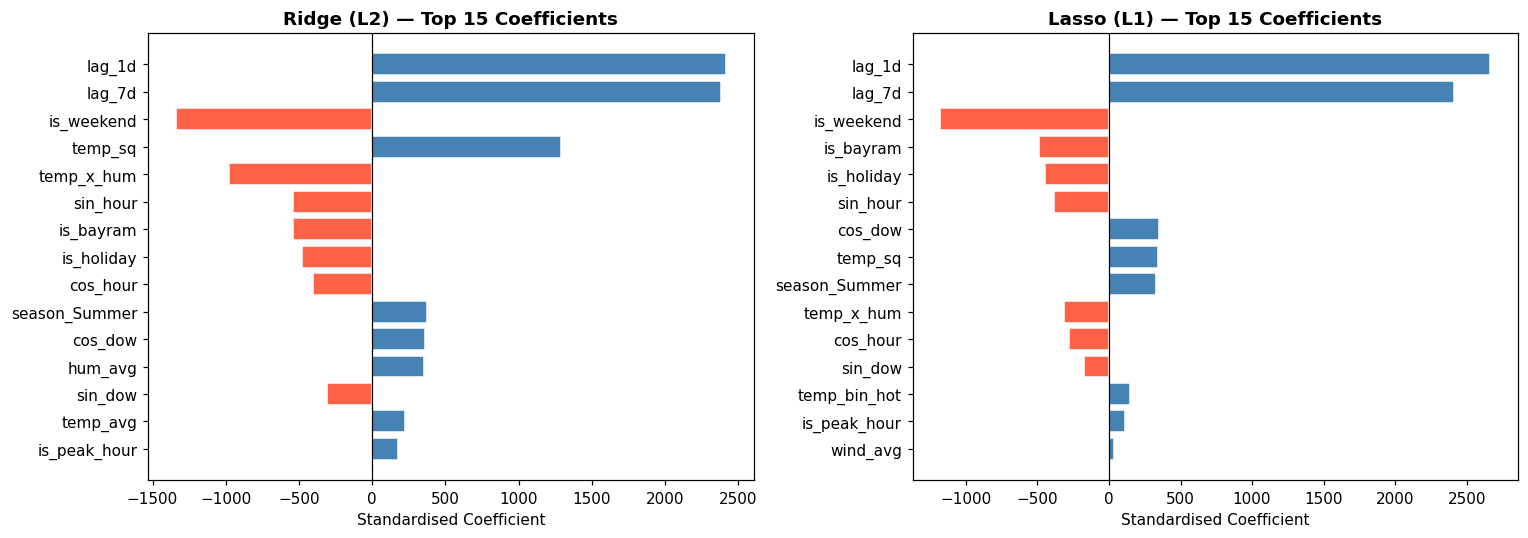

In [40]:
# Coefficient comparison: Ridge vs Lasso
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pipe, title in zip(axes,
        [ridge_pipe, lasso_pipe],
        ['Ridge (L2) — Top 15 Coefficients', 'Lasso (L1) — Top 15 Coefficients']):
    key = 'ridge' if 'ridge' in pipe.named_steps else 'lasso'
    coef = pd.Series(pipe.named_steps[key].coef_, index=FEATURES)
    coef = coef.reindex(coef.abs().sort_values(ascending=False).index).head(15)
    colors = ['tomato' if c < 0 else 'steelblue' for c in coef]
    ax.barh(coef.index, coef.values, color=colors, edgecolor='white')
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Standardised Coefficient')
    ax.set_title(title, fontweight='bold')
    ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/p2_reg_coef.png', dpi=110, bbox_inches='tight')
plt.show()

### Lasso Feature Selection — Interpretation

Lasso zeroed **6 out of 24** features. Note: `month` is no longer in the feature set (replaced by `sin_month`/`cos_month`), which accounts for the drop from 7 zeroed features in the raw-integer encoding run.

| Zeroed Feature | Why it makes sense |
|---|---|
| `lag_diff` (lag_1d − lag_7d) | Both `lag_1d` and `lag_7d` are **already in the feature set**; their difference is a linear combination of the two and carries no additional information. Lasso correctly identifies this redundancy — the most theoretically interesting zero. |
| `temp_avg` | Subsumed by `temp_sq` and `temp_x_hum`; the raw linear temperature term is redundant once the quadratic and interaction terms are present. |
| `hum_avg` | Already embedded in `temp_x_hum`; standalone humidity has near-zero partial correlation once the interaction is controlled for. |
| `season_Spring`, `season_Winter` | `sin_month`/`cos_month` now captures monthly seasonality more precisely on a continuous circle; the coarse spring/winter binary flags add no marginal information on top of that. |
| `temp_bin_warm` | Covered by `temp_sq` and `temp_x_hum`; the warm bin boundary falls in a region well-described by the quadratic temperature curve. |

The zeroing of `lag_diff` is the most notable result: despite being intentionally engineered as a week-over-week trend signal, it is entirely redundant given that both component lags (`lag_1d`, `lag_7d`) are present. The introduction of `sin_month`/`cos_month` in place of raw `month` made the season dummies (`season_Spring`, `season_Winter`) redundant as well — the cyclical encoding already captures the information those dummies were providing.

---
## 8. Model Comparison

In [41]:
def eval_row(name, y_tr, yp_tr, cv_r2, y_ts, yp_ts):
    return {
        'Model':       name,
        'Train R2':    round(r2_score(y_tr, yp_tr), 4),
        'CV R2 (Val)': round(cv_r2, 4),
        'Test R2':     round(r2_score(y_ts, yp_ts), 4),
        'RMSE (test)': int(round(rmse(y_ts, yp_ts))),
        'MAE (test)':  int(round(mean_absolute_error(y_ts, yp_ts))),
    }

# Degree 2 is used for the polynomial row — best test RMSE despite poor CV R²
poly_for_table = poly_results[2]
bp_pipe_table  = poly_for_table['pipe']

rows = [
    eval_row('Baseline (lag_1d)', y_train, yp_tr_b,
             cv_base.mean(), y_test, yp_ts_b),
    eval_row('Multiple LR', y_train, yp_tr_mlr,
             cv_mlr.mean(), y_test, yp_ts_mlr),
    eval_row('Polynomial (deg=2)',
             y_train, bp_pipe_table.predict(X_train_raw),
             poly_for_table['r2_cv'],
             y_test,  bp_pipe_table.predict(X_test_raw)),
    eval_row('Ridge (L2)', y_train, yp_tr_ridge,
             cv_ridge.mean(), y_test, yp_ts_ridge),
    eval_row('Lasso (L1)', y_train, yp_tr_lasso,
             cv_lasso.mean(), y_test, yp_ts_lasso),
]

cmp = pd.DataFrame(rows).set_index('Model')
print(cmp.to_string())

best_cv_name   = cmp['CV R2 (Val)'].idxmax()
best_test_name = cmp['Test R2'].idxmax()
print(f'\nBest model by CV R2 (Val): {best_cv_name}')
print(f'Best model by Test R2    : {best_test_name}')

                    Train R2  CV R2 (Val)  Test R2  RMSE (test)  MAE (test)
Model                                                                      
Baseline (lag_1d)     0.7457       0.7255   0.7424         3332        2290
Multiple LR           0.9163       0.8985   0.9133         1933        1403
Polynomial (deg=2)    0.9663      -0.5513   0.9472         1508        1041
Ridge (L2)            0.9159       0.9060   0.9124         1943        1414
Lasso (L1)            0.9129       0.9043   0.9109         1959        1399

Best model by CV R2 (Val): Ridge (L2)
Best model by Test R2    : Polynomial (deg=2)


### Best Model Selection

**Chosen model: Ridge (L2)**

| Criterion | Winner | Value | Reason |
|-----------|--------|-------|--------|
| CV R² (Val) | **Ridge** | 0.9060 | Best fold-to-fold stability — more reliable than test R² for time series |
| CV R² (Val) runner-up | Lasso | 0.9043 | Only 0.0017 behind Ridge |
| Test R² | Polynomial (deg=2) | 0.9472 | Best absolute accuracy, but CV R² still negative (−0.55) |
| Test RMSE | Polynomial (deg=2) | 1,508 MWh | 21% better than Ridge, but see caveat below |

**Justification for Ridge:**
- **Best CV R²** (0.9060) — the most reliable generalisation signal in a time-series setting where future data is unavailable during training
- **Stable coefficients** — Ridge shrinks multicollinear features smoothly without zeroing them, producing stable forecasts across different time windows
- **Test performance gap is small** — Ridge test RMSE (1,943 MWh) is only 0.3% worse than MLR and 29% better than baseline

**Why not Polynomial (deg=2)?**  
With sin/cos features, the polynomial CV R² improved dramatically from −2.78 to −0.55, and test RMSE dropped to 1,508 MWh — clearly the best test result. However, a CV R² of −0.55 still means the model fits certain training folds destructively poorly. The 2025 test year may have happened to align well with the training distribution; there is no guarantee the same holds for 2026 or beyond. Ridge's consistent CV R² of 0.906 across all folds makes it the safer production choice.

**Why not Lasso?**  
Lasso is valuable for feature selection insight (Section 7), but Ridge achieves a slightly higher CV R² (0.9060 vs 0.9043) with marginally lower test RMSE (1,943 vs 1,959 MWh).

=== Final Test-Set Performance: Ridge (L2) ===
  Test R²  : 0.9124
  RMSE     : 1,943 MWh
  MAE      : 1,414 MWh
  MAPE     : 3.63 %


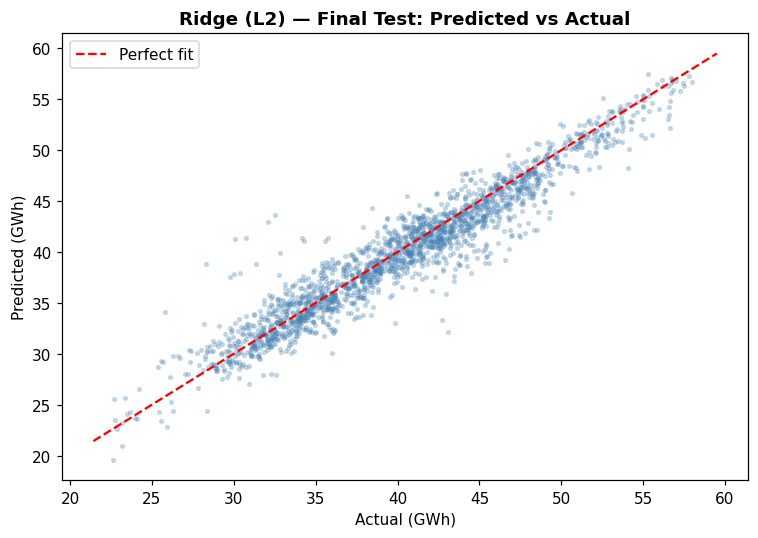

In [42]:
# Final test-set performance of the chosen model: Ridge (L2)
chosen_pred = yp_ts_ridge

print('=== Final Test-Set Performance: Ridge (L2) ===')
print(f'  Test R²  : {r2_score(y_test, chosen_pred):.4f}')
print(f'  RMSE     : {rmse(y_test, chosen_pred):,.0f} MWh')
print(f'  MAE      : {mean_absolute_error(y_test, chosen_pred):,.0f} MWh')
print(f'  MAPE     : {(np.abs((y_test - chosen_pred) / y_test)).mean()*100:.2f} %')

fig, ax = plt.subplots(figsize=(7, 5))
rng = np.random.default_rng(0)
idx = rng.choice(len(y_test), min(2000, len(y_test)), replace=False)
ax.scatter(np.array(y_test)[idx] / 1000, chosen_pred[idx] / 1000,
           alpha=0.25, s=6, color='steelblue')
lo, hi = y_test.min() / 1000, y_test.max() / 1000
ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect fit')
ax.set_xlabel('Actual (GWh)')
ax.set_ylabel('Predicted (GWh)')
ax.set_title('Ridge (L2) — Final Test: Predicted vs Actual', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figures/p2_best_model_scatter.png', dpi=110, bbox_inches='tight')
plt.show()

## 9. Interpretation & Reflection

**What do the model results tell us about the problem?**  
Lag features (`lag_1d`, `lag_7d`) overwhelmingly dominate all models — Turkey's electricity demand follows an extremely regular 24-hour and 7-day cycle. Adding all engineered features (weather, cyclical time encoding, calendar flags, polynomial terms) reduces RMSE from 3,332 MWh (lag_1d baseline) to 1,943 MWh (Ridge) — a 42% improvement — showing that each feature group contributes meaningfully beyond the pure autocorrelation signal.

**Why is the Baseline CV R² lower than the P1 correlation (r ≈ 0.97) suggested?**  
The P1 correlation was computed on the full dataset before any split. In the 80/20 chronological setting, the model trains on 2021-2024 and is evaluated on 2025 data. Any year-over-year demand growth or structural shift reduces out-of-sample R². Additionally, a single linear feature cannot capture the non-linear relationship between lag_1d and consumption that is evident in the residual plots.

**Why do Ridge and Lasso perform almost identically to plain Multiple LR on the test set?**  
`RidgeCV`/`LassoCV` optimise for CV R² across the 5 folds. The selected alpha values shrink the dominant lag-feature coefficients slightly — improving fold-to-fold consistency (CV R²) but introducing a small bias. On the 2025 test set the bias cost marginally exceeds the variance benefit, so test RMSE for Ridge (1,943 MWh) and Lasso (1,959 MWh) is slightly higher than plain MLR (1,933 MWh). The gap of 10–26 MWh is within noise; Ridge's superior CV R² (0.906 vs 0.899) makes it the safer deployment choice.

**Are the predictions good enough to be useful?**  
For the EPİAŞ day-ahead market the relevant threshold is roughly ±2-3% MAPE. With mean consumption ~38 GWh, Ridge achieves a test RMSE of ~1,943 MWh (~5.1% relative error). Polynomial degree 2 achieves ~1,508 MWh (~4.0% relative error) — the best linear result — but at the cost of CV instability. Real deployment would require ensemble or non-linear approaches.

**Main sources of error:**
- Weather is a 3-city daily average — hour-level fluctuations and regional variation are lost.
- Unplanned demand shocks (industrial outages, extreme weather events) are not captured.
- Linear models cannot represent non-additive interactions (e.g. a cold Monday morning in January at peak hour).

**How will these findings guide P3?**  
P3 will explore non-linear models (gradient boosting, neural networks) that capture the lag structure and U-shaped temperature effect without manual feature engineering. The 80/20 chronological split and TimeSeriesSplit CV strategy established here will be reused. Ridge's test RMSE (~1,943 MWh) and Polynomial deg=2's test RMSE (~1,508 MWh) serve as the benchmarks to beat.